# House Price Prediction

## Internship Project – Week 1

### Objective
The goal of this project is to predict house prices using property features such as area, bedrooms, bathrooms, stories, parking availability, and other amenities. Two regression models (Linear Regression and Random Forest Regressor) were trained and evaluated to determine which model predicts house prices more accurately.

In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad     

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [3]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


In [4]:
# Create a copy
df_clean = df.copy()

# Convert yes/no columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes':1,'no':0})

# One-hot encode furnishingstatus
df_clean = pd.get_dummies(
    df_clean,
    columns=['furnishingstatus'],
    drop_first=True
)

print(df_clean.head())
print("\nShape after encoding:", df_clean.shape)

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

In [5]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("price", axis=1)
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (436, 13)
Testing Set: (109, 13)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R²  : 0.6529242642153184


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
MAE : 1014947.3230122325
RMSE: 1399769.443949671
R²  : 0.6123598247296523


In [8]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison.sort_values("R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


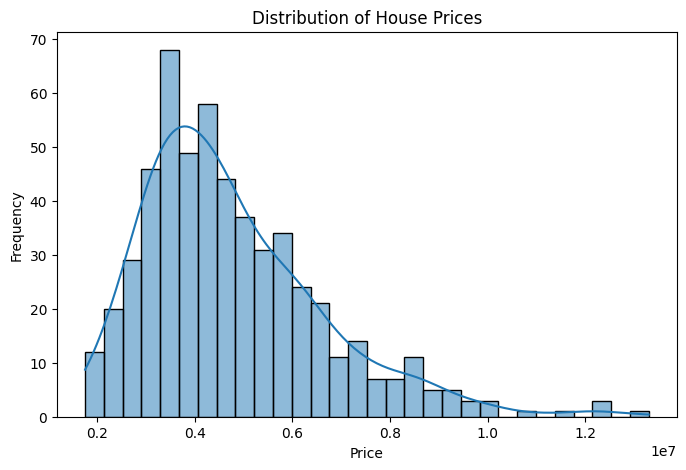

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/house_price_distribution.png")
plt.show()

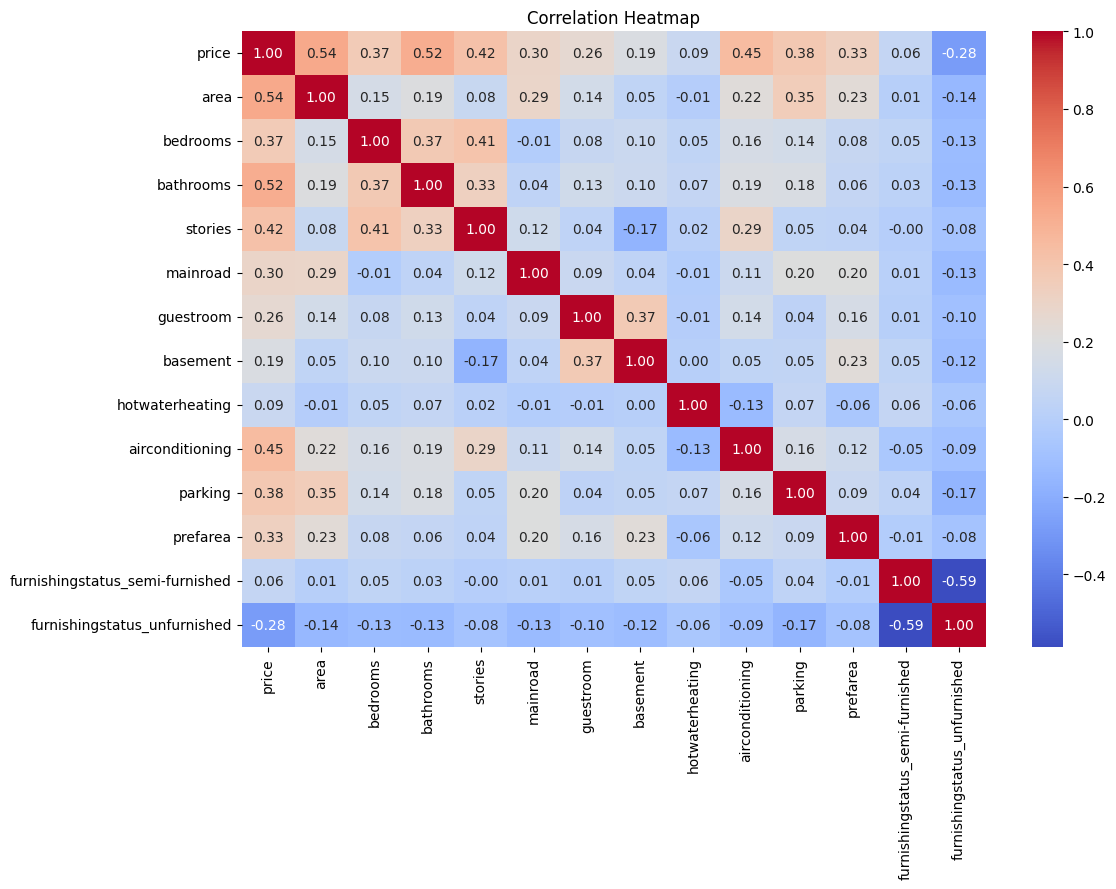

In [10]:
plt.figure(figsize=(12,8))

corr_matrix = df_clean.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")
plt.show()

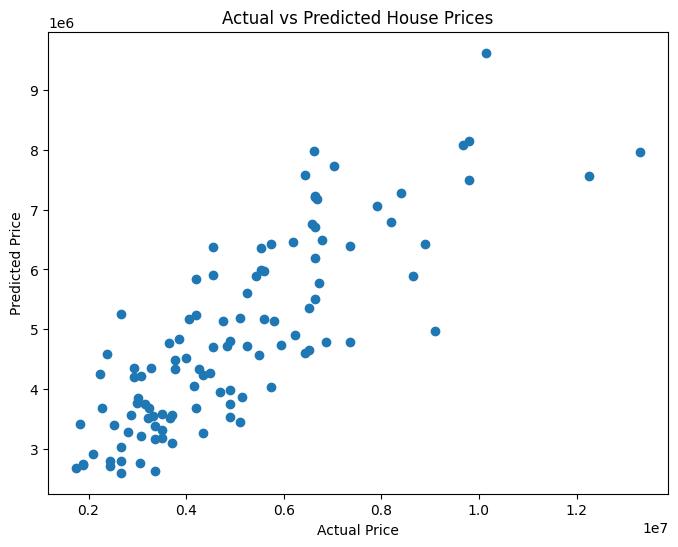

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [12]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lr_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head())

            Feature  Importance
0              area    0.138354
2         bathrooms    0.133920
3           stories    0.090208
8   airconditioning    0.087929
10         prefarea    0.038798


# Key Findings

1. The dataset contains 545 housing records and 13 property-related features.

2. No missing values or duplicate records were found, making the dataset clean and suitable for modeling.

3. The most influential features affecting house prices were:
   - Area
   - Bathrooms
   - Stories
   - Air Conditioning
   - Preferred Area

4. Linear Regression achieved the best performance with an R² score of approximately 0.65.

5. Linear Regression achieved the best performance with an R² score of 0.653, outperforming Random Forest (R² = 0.612)

6. The model can explain around 65% of the variation in house prices using the available features.

7. Larger houses with more amenities generally command higher prices.

8. Real estate businesses should prioritize properties with larger area, additional bathrooms, air conditioning, and preferred locations to maximize value.

In [13]:
import os
print(os.listdir("charts"))

['house_price_distribution.png', 'actual_vs_predicted.png', 'correlation_heatmap.png']


HousePricePrediction_NamanRoy/
│
├── analysis.ipynb
├── Housing.csv
├── summary.pdf
└── charts/
    ├── house_price_distribution.png
    ├── correlation_heatmap.png
    └── actual_vs_predicted.png

# Conclusion

A house price prediction system was developed using machine learning techniques. After preprocessing and analyzing the dataset, both Linear Regression and Random Forest models were trained and evaluated.

Linear Regression achieved the highest performance with an R² score of approximately 0.65, outperforming Random Forest on this dataset. Feature importance analysis showed that area, bathrooms, stories, air conditioning, and preferred area were the strongest contributors to house prices.

The project demonstrates how machine learning can assist real estate businesses in estimating property values and identifying factors that influence pricing decisions.